<a href="https://colab.research.google.com/github/rs3192398-del/Data-science-session/blob/main/proctect3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
np.random.seed(42)
data = pd.DataFrame({
    "hours_studied": np.random.randint(1, 10, 50),
    "attendance": np.random.randint(50, 100, 50),
})
data.head()

,hours_studied,attendance
0,7,53
1,4,51
2,8,55
3,5,91
4,7,53


In [9]:
x = data[["hours_studied", "attendance"]]

model = KMeans(n_clusters=3, random_state=42, n_init=10)
data["cluster"] = model.fit_predict(x)

data.head()

,hours_studied,attendance,cluster
0,7,53,1
1,4,51,1
2,8,55,1
3,5,91,0
4,7,53,1


In [10]:
score = silhouette_score(x, data["cluster"])
print("silhouette score:", score)
#

silhouette score: 0.5276411515754762


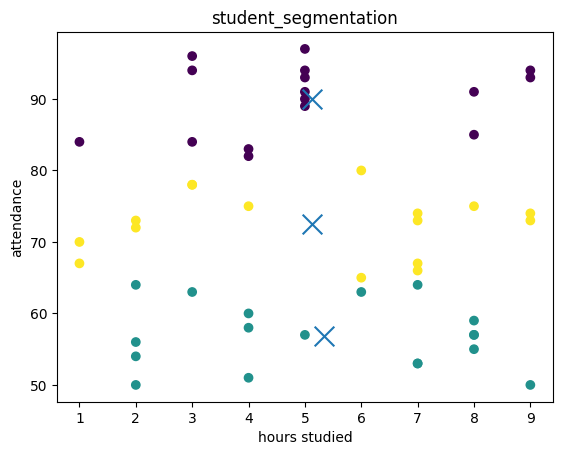

In [12]:
plt.scatter(data["hours_studied"], data["attendance"], c=data["cluster"])

centers = model.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker='x', s=200)

plt.xlabel("hours studied")
plt.ylabel("attendance")
plt.title("student_segmentation")
plt.show()

In [13]:
#Example: New student
#hours_studied = 6, attendance = 80

new_student = [[6, 80]]

predicted_cluster = model.predict(new_student)

print("New student belongs to cluster:", predicted_cluster[0])

New student belongs to cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [14]:
data.groupby("cluster").mean()

,hours_studied,attendance
cluster,,
0,5.125000,90.000000
1,5.333333,56.888889
2,5.125000,72.500000
